In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12
N_SEGS = 6
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True, 
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i = params[i]
        try:
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS))
        except Exception:
            pass
    return out


def prior_transform(u):
    logm1lim = [5.94889, 6.03054]
    logm2lim = [0.99336, 1.13038]
    alim = [0.62652, 0.99000]
    p0lim = [8.74104, 9.68094]
    e0lim = [0.37427, 0.41300]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.94889, 6.03054]
    logm2lim = [0.99336, 1.13038]
    alim = [0.62652, 0.99000]
    p0lim = [8.74104, 9.68094]
    e0lim = [0.37427, 0.41300]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u

Using dt=5s, T=1.0yr, TDI gen=1, N_segs=6
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris4_sc/int_1yr_s6'


In [ ]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [4]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [ ]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[0.49774954, 0.00920946, 0.14349752, 0.40544733, 0.7837196 ],
        [0.54678915, 0.02967673, 0.16224336, 0.35758885, 0.70025632],
        [0.508236  , 0.01926323, 0.14549561, 0.39825792, 0.74362934],
        ...,
        [0.61143294, 0.04268627, 0.19567601, 0.28973701, 0.67931615],
        [0.62004695, 0.0456496 , 0.19986034, 0.28037923, 0.6724373 ],
        [0.56720236, 0.03086943, 0.17508842, 0.33536087, 0.7161974 ]])]

In [ ]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([834.33371386, 660.31269181, 718.55337442, ..., 826.77810553,
        851.19753191, 839.24466653])]

In [7]:
sampler.now_covariances

[array([[ 4.34325683e-04,  1.11440129e-04,  2.02077015e-04,
         -4.48026081e-04, -3.57241036e-04],
        [ 1.11440129e-04,  2.97004676e-05,  5.17038952e-05,
         -1.14422354e-04, -9.32449398e-05],
        [ 2.02077015e-04,  5.17038952e-05,  9.40442725e-05,
         -2.08530072e-04, -1.65973246e-04],
        [-4.48026081e-04, -1.14422354e-04, -2.08530072e-04,
          4.62477223e-04,  3.67773709e-04],
        [-3.57241036e-04, -9.32449398e-05, -1.65973246e-04,
          3.67773709e-04,  2.96420490e-04]])]

In [8]:
np.argmax(logden_list)

45723

In [9]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[5.99582573, 0.99810132, 0.69144752, 9.04888015, 0.40169474]])

In [10]:
log_density(maxld_pt1)

array([28.6169887])

In [11]:
log_density([param_true])

array([28.53035408])

In [12]:
param_ranges = [(5.94889, 6.03054),
                (0.99336, 1.13038),
                (0.62652, 0.99000),
                (8.74104, 9.68094),
                (0.37427, 0.41300)
                ]
param_ranges

[(5.94889, 6.03054),
 (0.99336, 1.13038),
 (0.62652, 0.99),
 (8.74104, 9.68094),
 (0.37427, 0.413)]

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 9, 0.4]

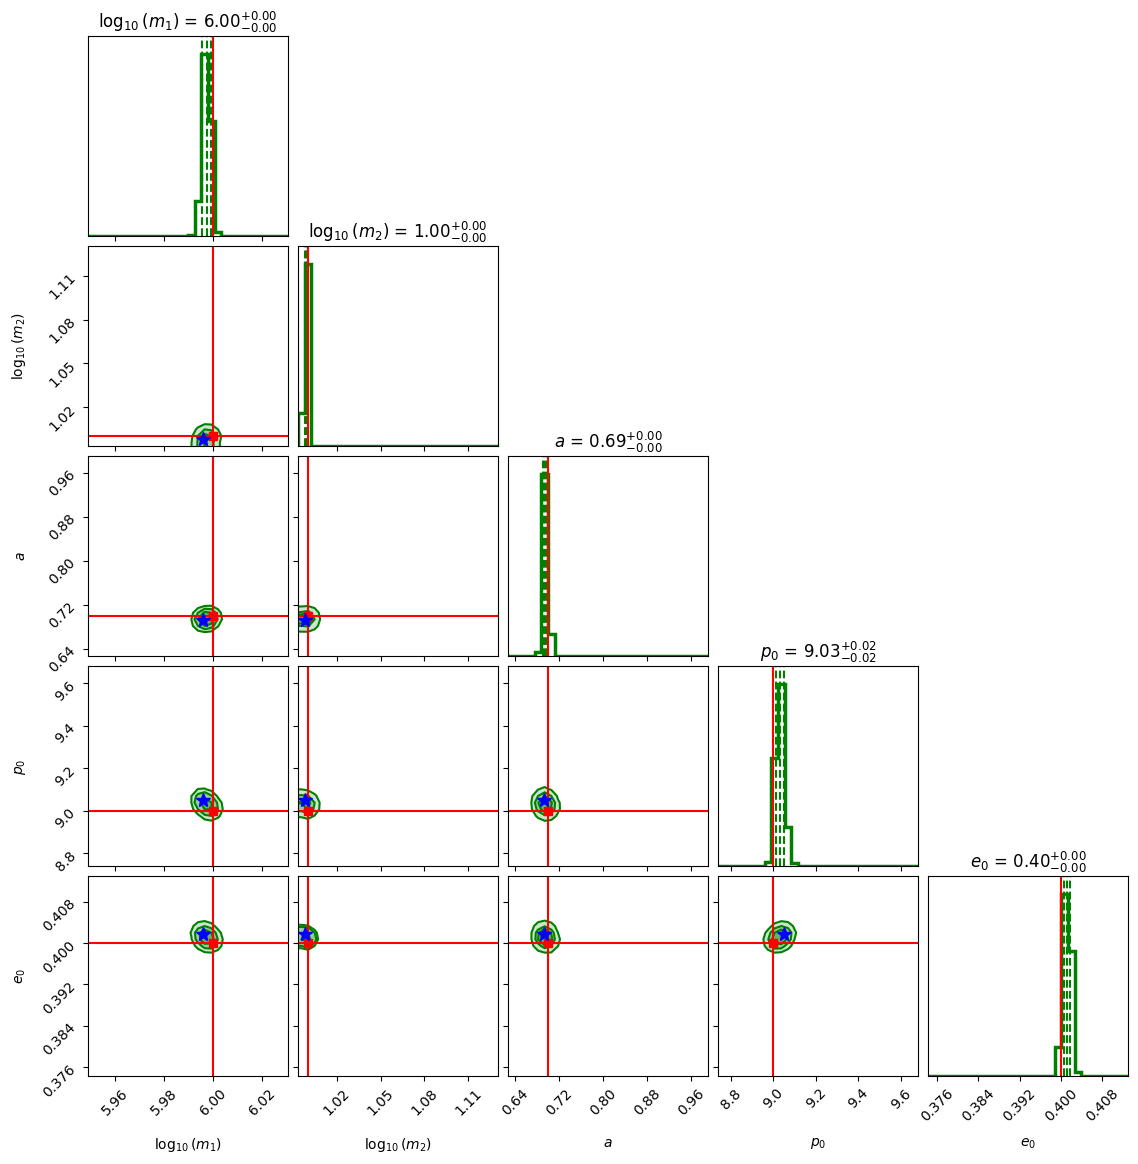

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




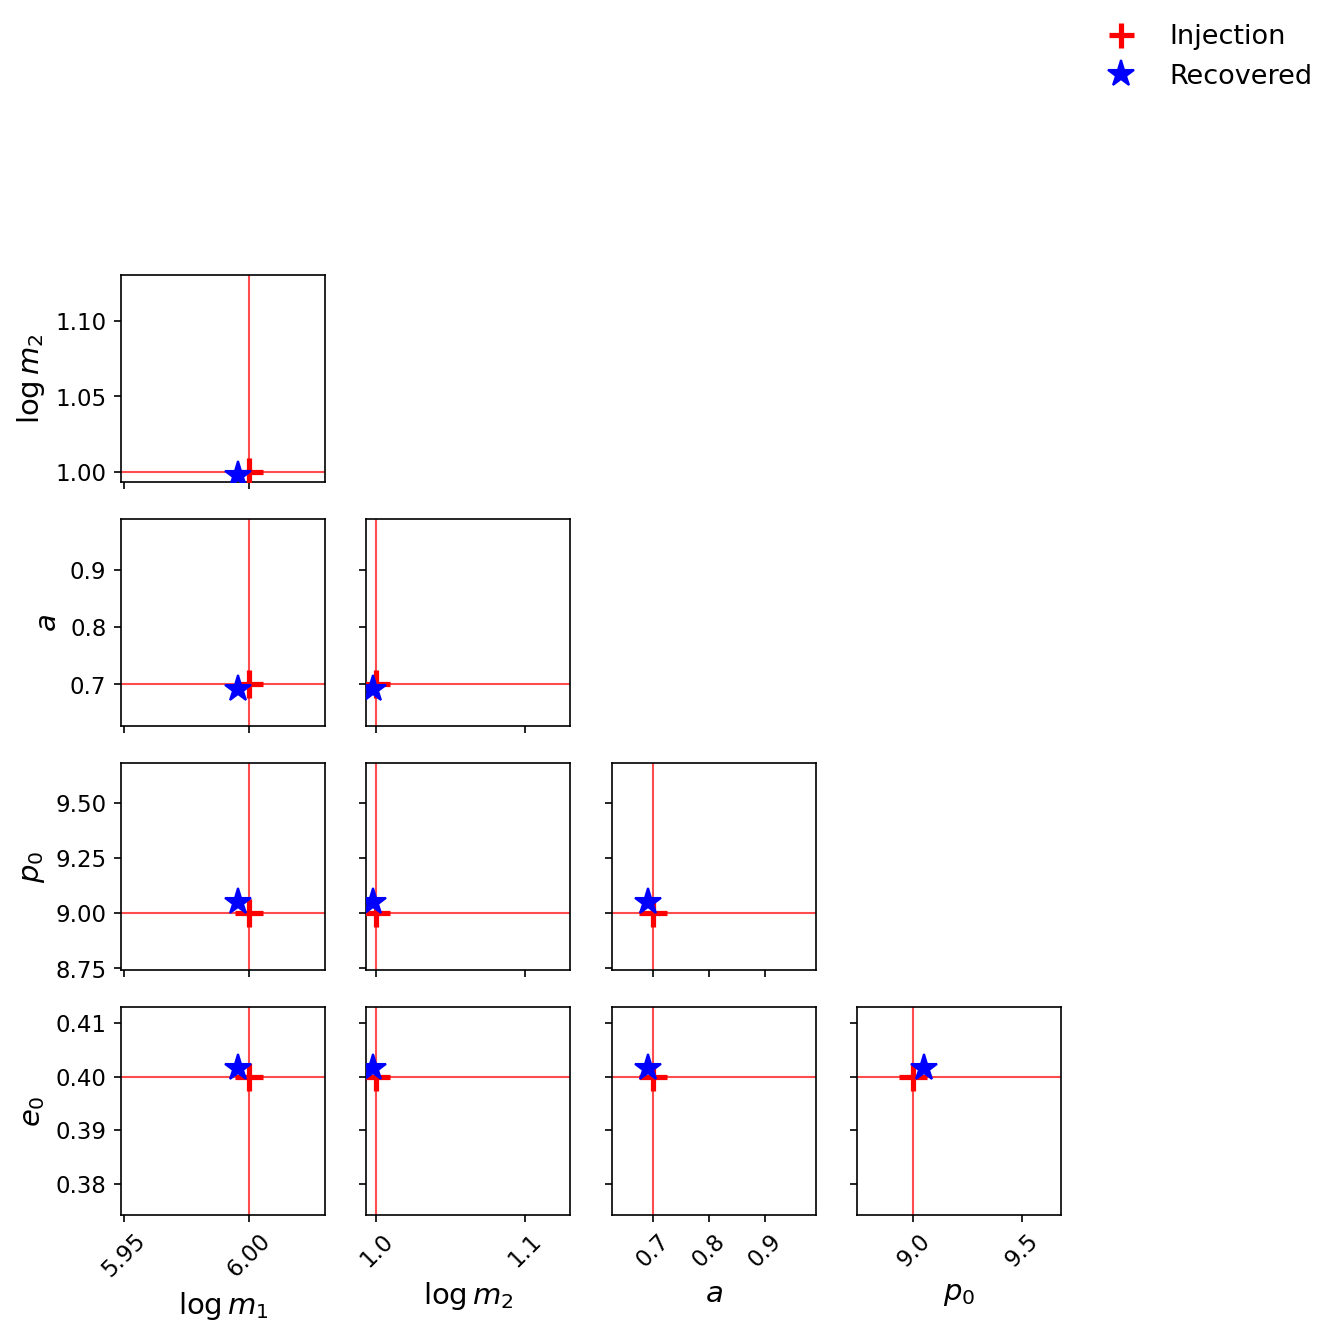

In [15]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

In [16]:
w_norm = weights / weights.sum()
ess = 1.0 / np.sum(w_norm**2)
print(f"ESS: {ess:.1f}  ({100*ess/len(weights):.2f}% of N={len(weights)})")

ESS: 149.3  (0.15% of N=100000)


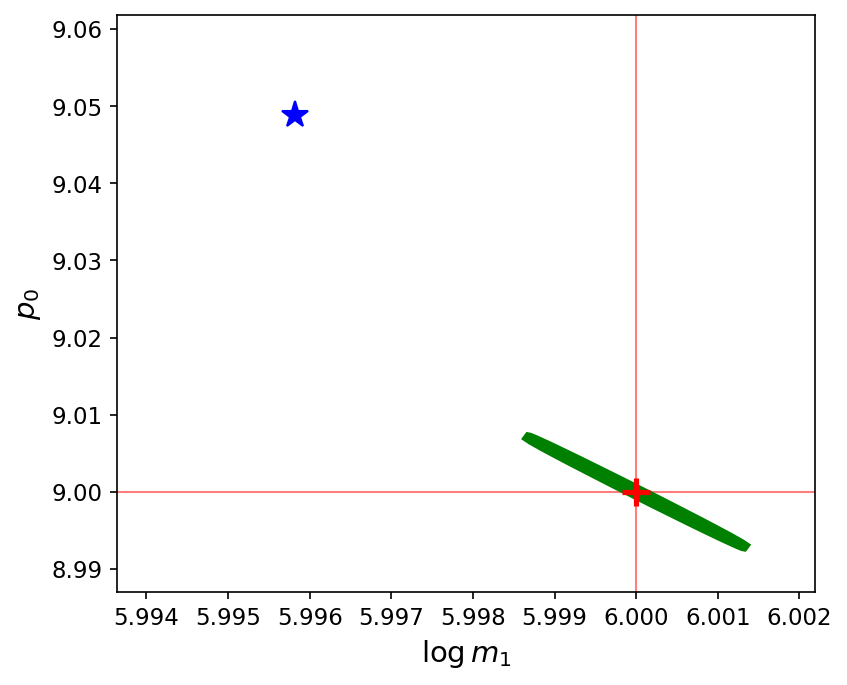

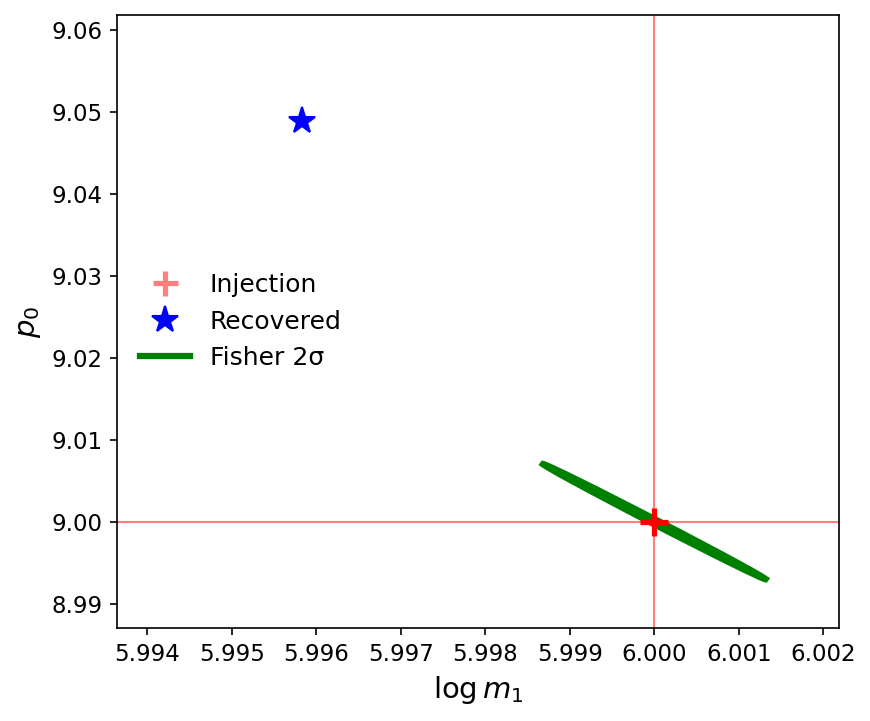

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

with open('/home/svu/e1498138/emri_search/work/cov_matrix_noise_1yr.pkl', 'rb') as f:
    cov = pickle.load(f)

def draw_cov_ellipse(ax, cx, cy, cov2d, n_sigma=1, **kwargs):
    vals, vecs = np.linalg.eigh(cov2d)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    ell = Ellipse(xy=(cx, cy),
                width=2 * n_sigma * np.sqrt(vals[0]),
                height=2 * n_sigma * np.sqrt(vals[1]),
                angle=angle, **kwargs)
    ax.add_patch(ell)

_pt  = np.asarray(param_true).ravel()
_map = np.asarray(maxld_pt1).ravel()
sigs = np.sqrt(np.diag(cov))

j, i = 0, 3   # x = log10(m1), y = p0
cov2d = cov[np.ix_([j, i], [j, i])]

xlo = min(_pt[j], _map[j]);  xhi = max(_pt[j], _map[j])
ylo = min(_pt[i], _map[i]);  yhi = max(_pt[i], _map[i])
xpad = (xhi - xlo) * 0.05 + 3 * sigs[j]
ypad = (yhi - ylo) * 0.05 + 3 * sigs[i]

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_xlim(xlo - xpad, xhi + xpad)
ax.set_ylim(ylo - ypad, yhi + ypad)

ax.axvline(_pt[j], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.axhline(_pt[i], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.plot(_pt[j], _pt[i], '+', color='red', ms=13, mew=2.5, zorder=3)
ax.plot(_map[j], _map[i], '*', color='blue', ms=13, zorder=4)

draw_cov_ellipse(ax, _pt[j], _pt[i], cov2d,
                n_sigma=2, facecolor='none', edgecolor='green', lw=5, zorder=2)

ax.set_xlabel(r'$\log m_1$')
ax.set_ylabel(r'$p_0$')
sigs = np.sqrt(np.diag(cov))

j, i = 0, 3   # x = log10(m1), y = p0
cov2d = cov[np.ix_([j, i], [j, i])]
a
xlo = min(_pt[j], _map[j]);  xhi = max(_pt[j], _map[j])
ylo = min(_pt[i], _map[i]);  yhi = max(_pt[i], _map[i])
xpad = (xhi - xlo) * 0.05 + 3 * sigs[j]
ypad = (yhi - ylo) * 0.05 + 3 * sigs[i]

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_xlim(xlo - xpad, xhi + xpad)
ax.set_ylim(ylo - ypad, yhi + ypad)

ax.axvline(_pt[j], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.axhline(_pt[i], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.plot(_pt[j], _pt[i], '+', color='red', ms=13, mew=2.5, zorder=3)
ax.plot(_map[j], _map[i], '*', color='blue', ms=13, zorder=4)

draw_cov_ellipse(ax, _pt[j], _pt[i], cov2d,
                n_sigma=2, facecolor='none', edgecolor='green', lw=3, zorder=2)

ax.set_xlabel(r'$\log  m_1$')
ax.set_ylabel(r'$p_0$')

legend_handles = [
    Line2D([0], [0], color='red',   marker='+', ls='', ms=12, mew=2.5, alpha=0.5, label='Injection'),
    Line2D([0], [0], color='blue',  marker='*', ls='', ms=13,           label='Recovered'),
    Line2D([0], [0], color='green', ls='-',  lw=3,                      label='Fisher 2σ'),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

# connection plot

In [18]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1,-1)
proc1_maxld_pt

array([[5.99582573, 0.99810132, 0.69144752, 9.04888015, 0.40169474]])

In [19]:
from scipy.stats import chi2

# --- Mahalanobis distance: does this run's posterior ellipsoid contain the truth? ---
w_norm_mh = weights / weights.sum()

rng_mh = np.random.default_rng(0)
idx_mh = rng_mh.choice(len(samples), size=50_000, replace=True, p=w_norm_mh)
cov_posterior = np.cov(samples[idx_mh].T)

mu_center = maxld_pt1[0]
true_pt   = np.array(param_true)

mu_center = maxld_pt1[0]
true_pt   = np.array(param_true)
delta     = true_pt - mu_center

maha = np.sqrt(delta @ np.linalg.inv(cov_posterior) @ delta)
k    = len(mu_center)
covered_frac = chi2.cdf(maha**2, df=k)   # posterior-mass fraction enclosed by an ellipsoid this size

print(f"mu_center (max-logden pt): {mu_center}")
print(f"param_true:                {true_pt}")
print(f"delta (true - mu_center):  {delta}")
print()
print(f"Mahalanobis distance of truth from mu_center: {maha:.3f}")
print(f"Equivalent enclosed posterior-mass fraction:   {covered_frac:.6f}")
print(f"  -> need an ellipsoid of Mahalanobis radius >= {maha:.2f} to contain the truth")
for n_sigma in [1, 2, 3, 6, 10]:
    print(f"  r={n_sigma:>2} ellipsoid: truth {'INSIDE' if maha <= n_sigma else 'OUTSIDE'}")

TypeError: object of type 'numpy.float64' has no len()

In [20]:
# --- Build the ellipsoid the same way old/precompute_lhs_paris3.py does, and test if truth is inside ---
N_SIGMA_PRIOR = 15.0   # old/precompute_lhs_paris3.py uses 3.0 (the _noise version uses 6.0)

_p2_lo = np.array([5.6, 0.8, 0.3, 8.0, 0.2])
_p2_hi = np.array([6.4, 1.3, 0.99, 11.0, 0.5])

sigma_diag = np.sqrt(np.diag(cov_posterior))
ellipse_lo = np.clip(mu_center - N_SIGMA_PRIOR * sigma_diag, _p2_lo, _p2_hi)
ellipse_hi = np.clip(mu_center + N_SIGMA_PRIOR * sigma_diag, _p2_lo, _p2_hi)

print(f"{N_SIGMA_PRIOR:.0f}-sigma bounding box (axis-aligned, clipped to prior) vs. truth:")
param_names = ['logm1', 'logm2', 'a', 'p0', 'e0']
for i, name in enumerate(param_names):
    inside = ellipse_lo[i] <= true_pt[i] <= ellipse_hi[i]
    print(f"  {name:>6}: [{ellipse_lo[i]:.5f}, {ellipse_hi[i]:.5f}]   truth={true_pt[i]:.5f}   "
        f"{'inside' if inside else 'OUTSIDE'}")

box_inside = np.all((ellipse_lo <= true_pt) & (true_pt <= ellipse_hi))
print(f"\nTruth inside {N_SIGMA_PRIOR:.0f}-sigma bounding box (all dims)?     {box_inside}")

# the *actual* ellipsoid used for LHS sampling is r <= N_SIGMA_PRIOR in Mahalanobis units
ellipsoid_inside = maha <= N_SIGMA_PRIOR
print(f"Truth inside {N_SIGMA_PRIOR:.0f}-sigma covariance ellipsoid (maha={maha:.1f} <= {N_SIGMA_PRIOR:.0f})?  {ellipsoid_inside}")

15-sigma bounding box (axis-aligned, clipped to prior) vs. truth:
   logm1: [5.97028, 6.02137]   truth=6.00000   inside
   logm2: [1.30000, 1.30000]   truth=1.00000   OUTSIDE
       a: [0.99000, 0.99000]   truth=0.70000   OUTSIDE
      p0: [8.00000, 8.00000]   truth=9.00000   OUTSIDE
      e0: [0.50000, 0.50000]   truth=0.40000   OUTSIDE

Truth inside 15-sigma bounding box (all dims)?     False
Truth inside 15-sigma covariance ellipsoid (maha=522590.8 <= 15)?  False


In [21]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [22]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [23]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [24]:
logden_theory_proc1

array([28.6169887 , 28.62177209, 28.60969584, 28.57427001, 28.49306213,
       28.41865608, 28.33459305, 28.27695345, 28.31083349, 28.37087723,
       28.39859487, 28.40987081, 28.46039629, 28.50124217, 28.50488487,
       28.53365511, 28.50669213, 28.43545036, 28.3918873 , 28.36505827,
       28.36728034, 28.35630984, 28.41096449, 28.45376056, 28.47432465,
       28.47974945, 28.46061465, 28.49650265, 28.50712227, 28.50456836,
       28.49960932, 28.47472156, 28.48738474, 28.4640629 , 28.46438328,
       28.40970955, 28.42572138, 28.40759442, 28.45882864, 28.47323492,
       28.44750108, 28.46869071, 28.50367894, 28.51538659, 28.55230258,
       28.55334777, 28.54867999, 28.546719  , 28.55316066, 28.53035408])

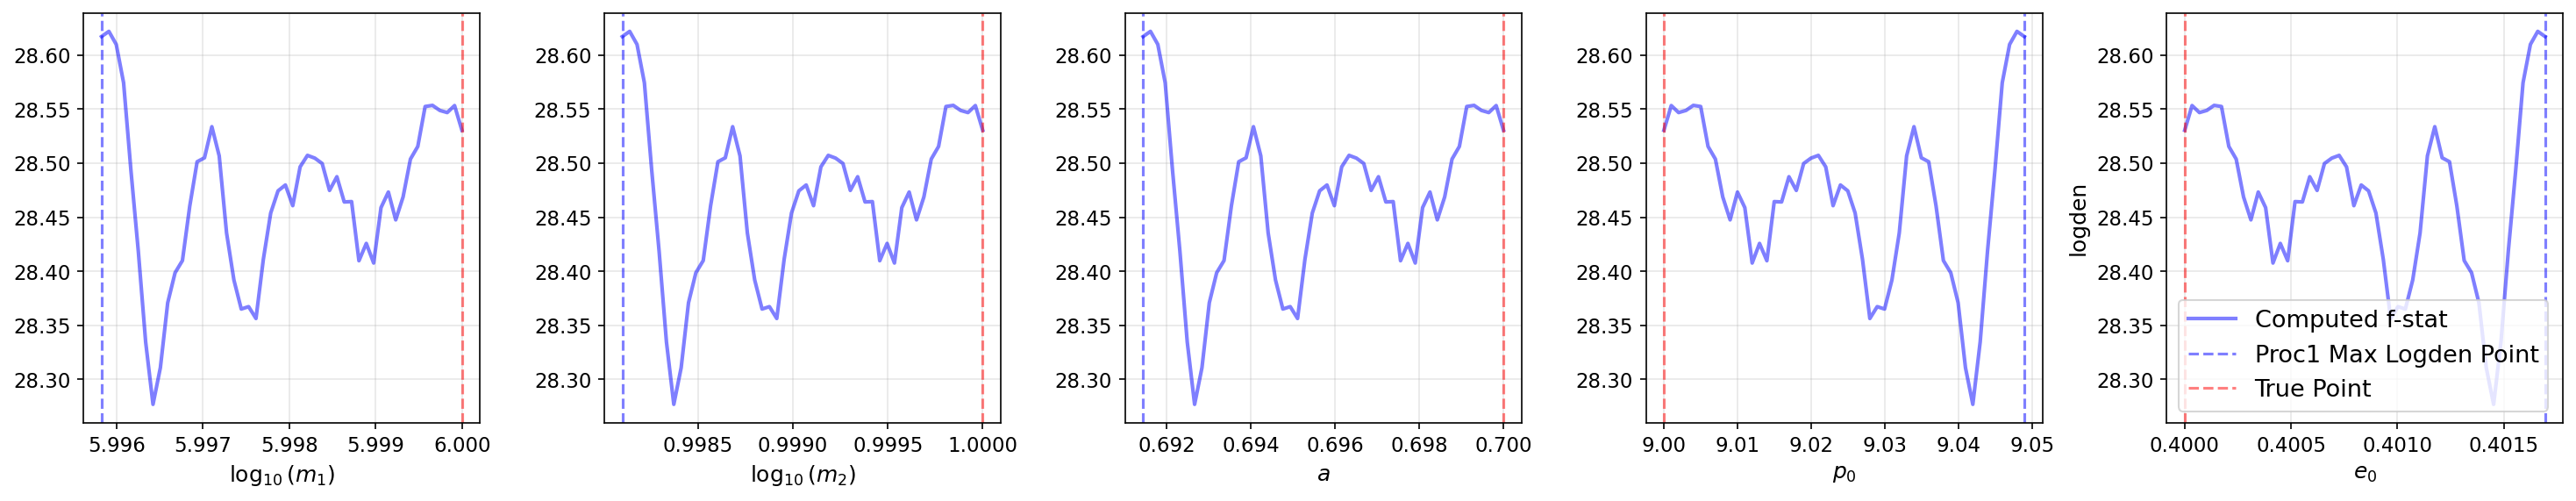

In [25]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [26]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [27]:
i = 0  # logm1
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

t_values_logm1 = np.sort(np.concatenate([t_values_logm1, [t_true, t_secondary]]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]


In [28]:
logden_tm = log_density(line_points_logm1.T)


In [29]:
logden_tm

array([13.49685028, 13.41992731, 13.33802572, 13.13900251, 13.02160329,
       13.02614783, 12.7903454 , 13.21701118, 13.36218816, 13.20175389,
       13.41345575, 12.9707509 , 13.36343816, 13.58641317, 13.09215009,
       13.28843011, 13.2094977 , 13.12940075, 13.07955125, 13.15968856,
       13.36733638, 13.54323416, 13.06588158, 13.53613207, 13.52285148,
       13.19540843, 13.48868583, 13.80919824, 13.71363951, 13.78918052,
       14.10911377, 14.14124012, 14.44741439, 14.61881366, 14.40385298,
       14.2185206 , 14.58328423, 14.7922113 , 14.68799567, 14.59612656,
       14.3576031 , 14.61754864, 14.52185365, 14.53175175, 14.64270146,
       14.78478289, 14.94075727, 15.04644873, 14.90881425, 15.02785553,
       14.92382294, 14.68701707, 14.87657818, 14.98077399, 14.90015161,
       15.10117099, 15.30144038, 15.19341168, 15.2552701 , 15.5907557 ,
       15.75394085, 15.76416984, 16.15391662, 16.46497311, 16.66074723,
       16.70206312, 17.23275785, 17.59817912, 18.09092085, 18.11

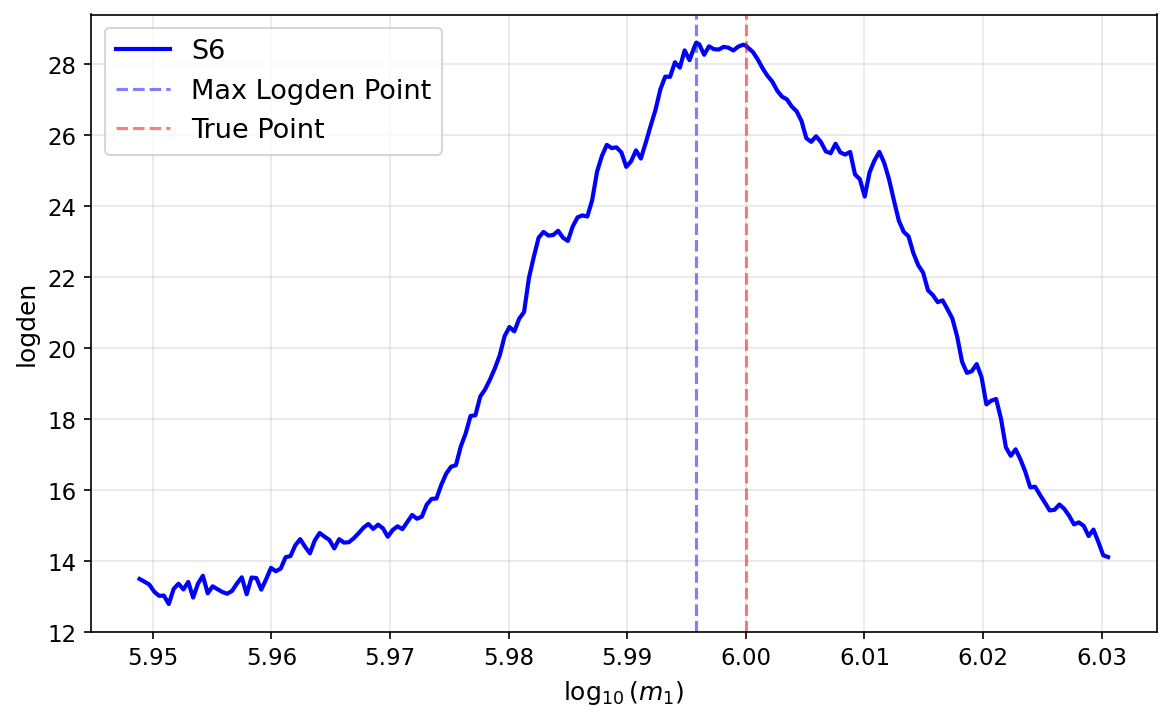

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='S6')
# ax.plot(line_points_logm1[0], logden_pure, '-', color='red', linewidth=2, label='f-stat (3mth) pure')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()